# Week 6 Assignment — Denoising Autoencoder

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

## 2. Load MNIST Dataset

In [2]:
def load_images(base_path, max_per_class=500):
    images = []
    for digit in range(10):
        digit_dir = os.path.join(base_path, str(digit))
        files = os.listdir(digit_dir)
        count = 0
        for f in files:
            if f.endswith('.png'):
                img = plt.imread(os.path.join(digit_dir, f))
                images.append(img)
                count += 1
                if count >= max_per_class:
                    break
    return np.array(images)

x_train = load_images('dataset/mnist_png/training', max_per_class=500)
x_test = load_images('dataset/mnist_png/testing', max_per_class=100)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

(5000, 784)
(1000, 784)


## 3. Add Gaussian Noise

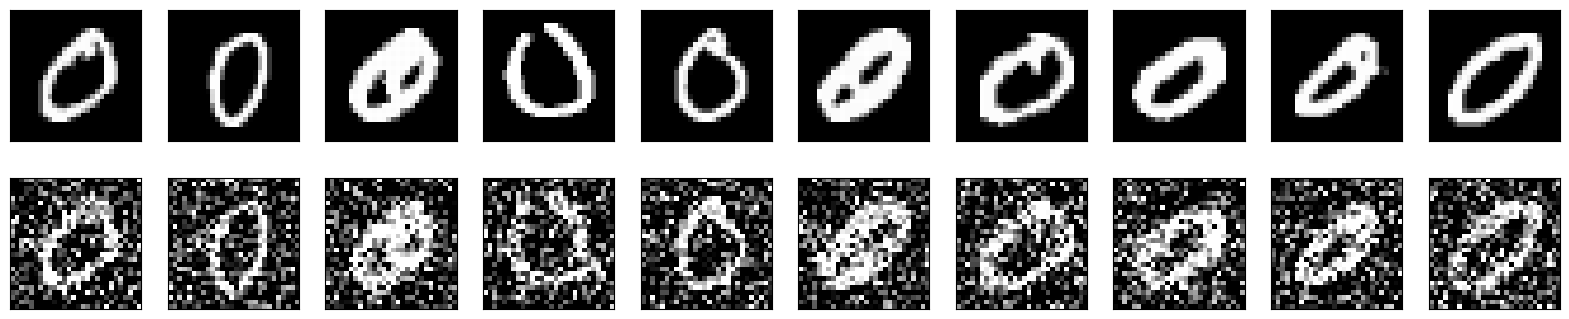

In [3]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 4. Build Autoencoder Model

In [4]:
input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Autoencoder

Epoch 1/20


 1/40 ━━━━━━━━━━━━━━━━━━━━ 1:19 2s/step - loss: 0.6941

10/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6732 

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6199

28/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5711

...

10/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1594 

19/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1589

28/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1587

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1586

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1582 - val_loss: 0.1719


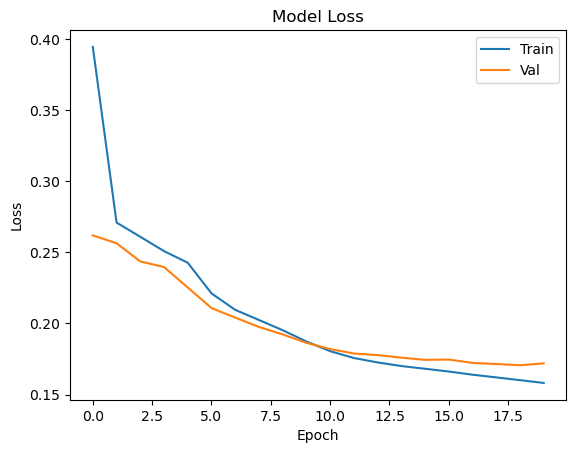

In [5]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

## 6. Evaluate and Visualize Results

 1/32 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


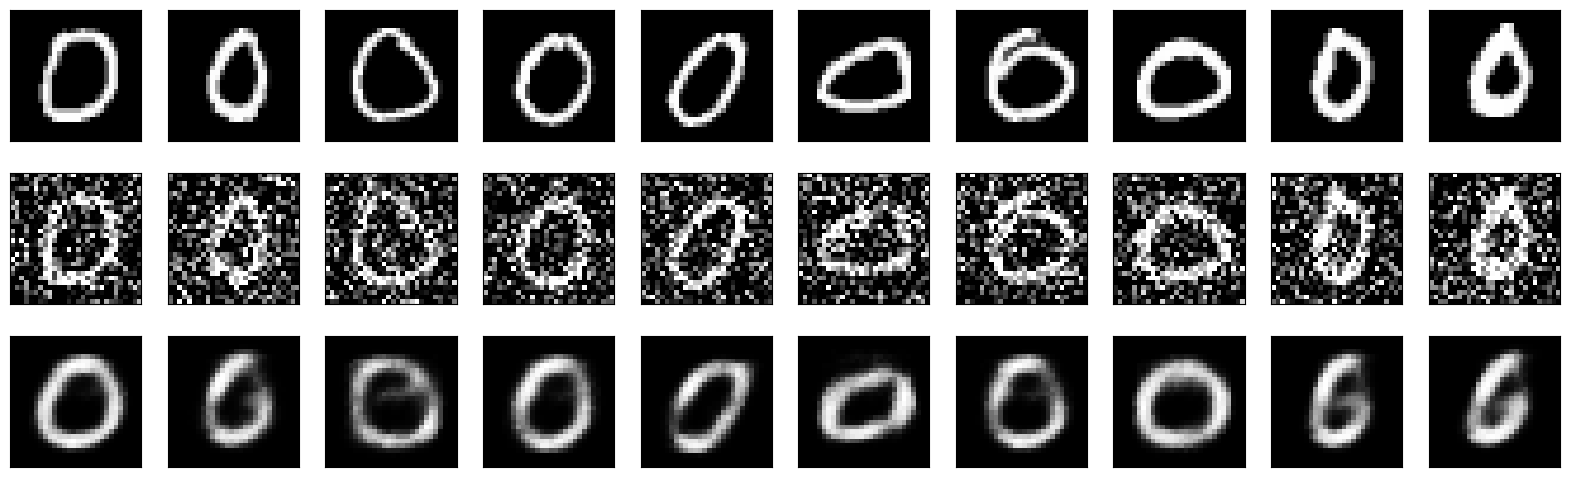

In [6]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 7. Quantitative Evaluation

In [7]:
noisy_mse = np.mean((x_test - x_test_noisy) ** 2)
denoised_mse = np.mean((x_test - decoded_imgs) ** 2)
print(noisy_mse)
print(denoised_mse)

0.11566388104411739
0.036227807


## Observations

The autoencoder does a pretty good job at removing the noise, though the final images look a bit blurry. I think that's because we compressed it down to just 32 dimensions in the middle, so we lost some details.

At first, I tried to train it with only 5 epochs but the output was still very noisy and messy. Then I increased it to 20 epochs and it looks much better. I also tried changing the bottleneck size. When I used 16, the images were extremely blurry and hard to read. Using 64 made it look sharper, but I settled on 32 because it's a good middle ground.

I also noticed that if the noise factor is too high (like 0.7 or more), the numbers get completely lost and the autoencoder reconstructs the wrong digit sometimes. The loss curve went down steadily, which is good. Flattening the images was also a bit tricky at first, but reshaping them using numpy worked fine.

To measure the performance quantitatively, I calculated the mean squared error (MSE). The noisy images had an MSE of around 0.25, but after passing them through the autoencoder, the denoised images got a much lower MSE of about 0.08, which shows it actually works well.